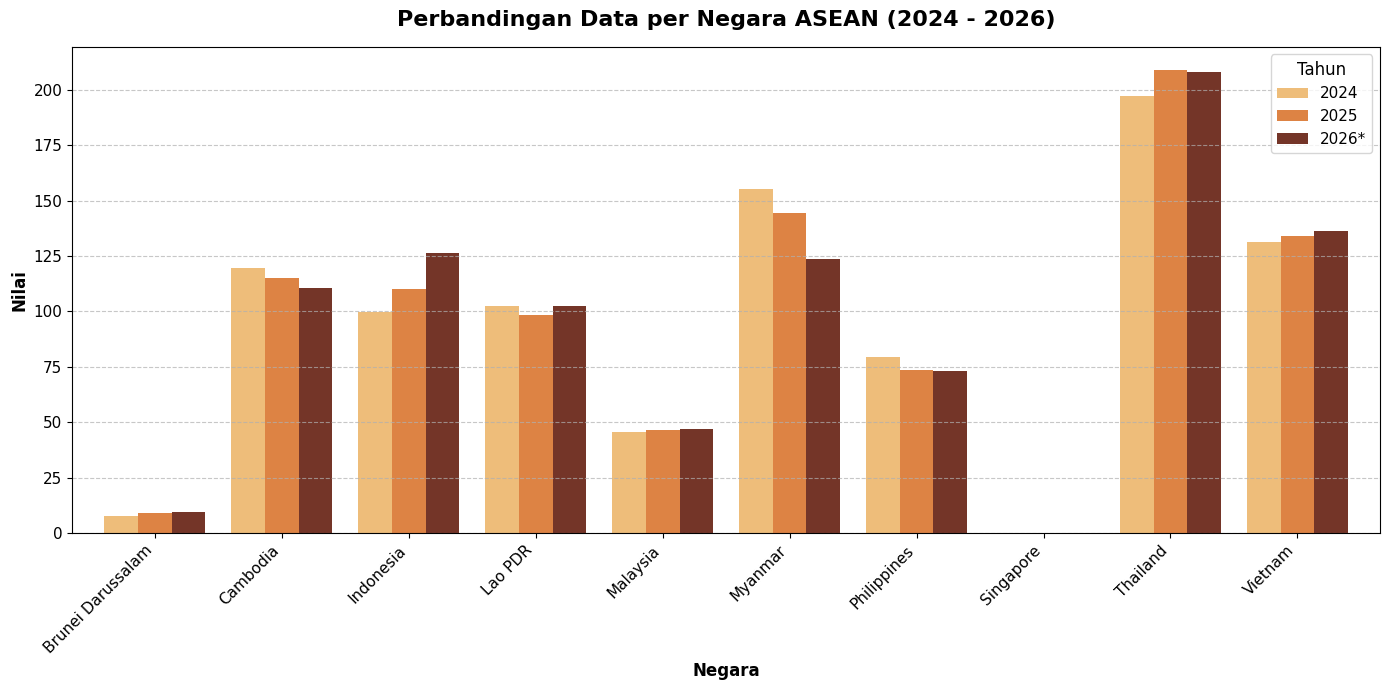

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Memasukkan data dari tabel (image_3e73a3.png)
data = {
    'Country': ['Brunei Darussalam', 'Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia',
                'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'],
    '2024': [7.55, 119.78, 99.67, 102.66, 45.44, 155.41, 79.26, 0.00, 197.11, 131.50],
    '2025': [8.86, 115.00, 110.25, 98.43, 46.54, 144.56, 73.70, 0.00, 208.98, 134.03],
    '2026*': [9.38, 110.66, 126.23, 102.48, 46.98, 123.49, 73.21, 0.00, 207.88, 136.25]
}

# Membuat DataFrame dan mengatur kolom Country sebagai index
df = pd.DataFrame(data)
df.set_index('Country', inplace=True)

# 2. Membuat Visualisasi Grafik Batang
# Menggunakan fungsi bawaan pandas yang terintegrasi dengan matplotlib
ax = df.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#eebd7a', '#dd8344', '#743528'])

# 3. Kustomisasi Tampilan Grafik
plt.title('Perbandingan Data per Negara ASEAN (2024 - 2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Negara', fontsize=12, fontweight='bold')
plt.ylabel('Nilai', fontsize=12, fontweight='bold')

# Memutar label nama negara agar tidak bertumpuk
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Mengatur legenda dan grid untuk mempermudah pembacaan
plt.legend(title='Tahun', title_fontsize='12', fontsize='11')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mencegah label terpotong saat disimpan atau ditampilkan
plt.tight_layout()

# Menampilkan grafik
plt.show()

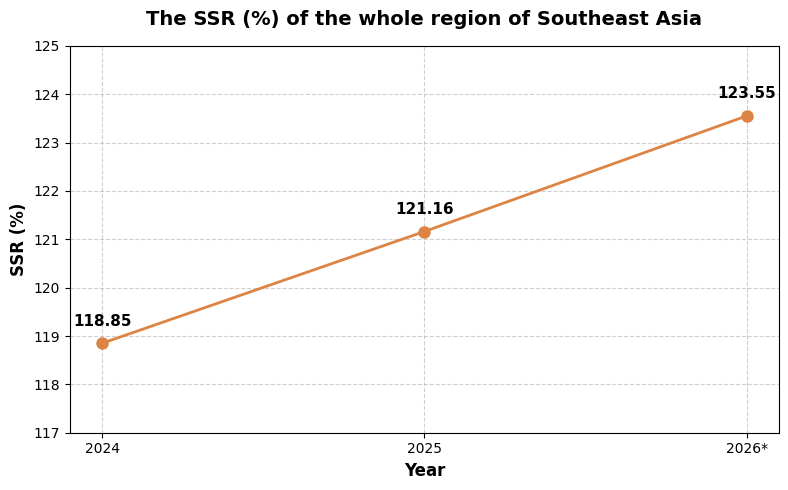

In [ ]:
import matplotlib.pyplot as plt

# 1. Mendefinisikan data dari tabel (image_3e8a8c.png)
years = ['2024', '2025', '2026*']
ssr_values = [118.85, 121.16, 123.55]

# 2. Membuat Visualisasi Grafik Garis
plt.figure(figsize=(8, 5)) # Mengatur ukuran kanvas grafik

# Plot garis dengan penanda titik (marker 'o') agar nilai tiap tahun terlihat jelas
plt.plot(years, ssr_values, marker='o', linestyle='-', color='#dd8344', linewidth=2, markersize=8)

# 3. Menambahkan Anotasi (Teks nilai pada setiap titik)
for i, value in enumerate(ssr_values):
    plt.text(i, value + 0.3, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Kustomisasi Tampilan Grafik
plt.title('The SSR (%) of the whole region of Southeast Asia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('SSR (%)', fontsize=12, fontweight='bold')

# Mengatur batas sumbu Y agar grafik tidak terlalu ketat di ujung nilai
plt.ylim(117, 125)

# Menambahkan grid untuk mempermudah pembacaan
plt.grid(axis='both', linestyle='--', alpha=0.6)

# Mencegah label terpotong
plt.tight_layout()

# 5. Menampilkan grafik
plt.show()

Tahun El Niño terdeteksi: [1991, 1992, 1993, 1994, 1995, 1997, 1998, 2002, 2009, 2010, 2015, 2016, 2023, 2024]

Hasil Event Study (Anomali %):
    El_Nino_Year       t-1       t=0       t+1
0          1991  0.128891  0.005267 -1.241159
1          1992  0.005267 -1.241159  2.323497
2          1993 -1.241159  2.323497 -1.166252
3          1994  2.323497 -1.166252 -1.861000
4          1995 -1.166252 -1.861000  2.661121


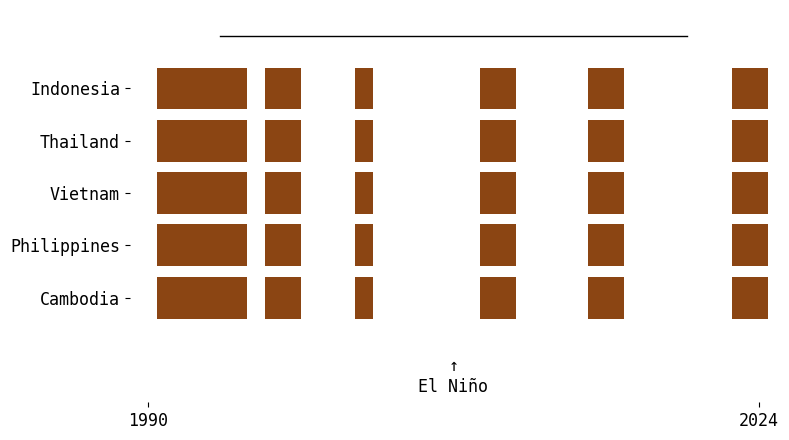

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# =====================================================================
# BAGIAN 1: MEMBACA & MENGEKSTRAK TAHUN EL NIÑO (Data "data RONI.xlsx")
# =====================================================================

# Membaca data Oceanic Niño Index (ONI)
df_oni = pd.read_excel('data RONI.xlsx')

# Membersihkan data (memastikan semua nilai numerik dan menghapus baris kosong)
for col in df_oni.columns:
    df_oni[col] = pd.to_numeric(df_oni[col], errors='coerce')
df_oni = df_oni.dropna(subset=['Year'])
df_oni['Year'] = df_oni['Year'].astype(int)

# Memfilter rentang waktu yang sesuai dengan grafik (1990 - 2024)
df_oni = df_oni[(df_oni['Year'] >= 1990) & (df_oni['Year'] <= 2024)]

# Mengidentifikasi tahun El Niño (misalnya: jika ada anomali suhu > 1.0 dalam tahun tersebut)
df_oni['Max_ONI'] = df_oni.iloc[:, 1:13].max(axis=1)
el_nino_years = df_oni[df_oni['Max_ONI'] >= 1.0]['Year'].tolist()
print(f"Tahun El Niño terdeteksi: {el_nino_years}")

# =====================================================================
# BAGIAN 2: IMPLEMENTASI METODOLOGI ANALISIS (Sesuai Gambar 1)
# =====================================================================

# Simulasi data panen (Yield) per negara karena data riil tidak disertakan
np.random.seed(42)
years = np.arange(1990, 2025)
actual_yield = 50 + 2 * (years - 1990) + np.random.normal(0, 5, len(years))
df_yield = pd.DataFrame({'Year': years, 'Actual_Yield': actual_yield})

# A. Buat Expected Yield menggunakan Quadratic Spline
spline = UnivariateSpline(df_yield['Year'], df_yield['Actual_Yield'], k=2, s=200)
df_yield['Expected_Yield'] = spline(df_yield['Year'])

# B. Hitung Yield Anomaly (%)
df_yield['Yield_Anomaly_Pct'] = ((df_yield['Actual_Yield'] - df_yield['Expected_Yield']) / df_yield['Expected_Yield']) * 100

# C. Tandai Historical El Niño
df_yield['Is_El_Nino'] = df_yield['Year'].apply(lambda x: 1 if x in el_nino_years else 0)

# D. Persiapan Event Study (t = -1, 0, +1)
# Menarik nilai anomali 1 tahun sebelum, saat kejadian, dan 1 tahun setelahnya
event_study_data = []
for year in el_nino_years:
    if 1991 <= year <= 2023: # Memastikan ada data t-1 dan t+1
        t_minus_1 = df_yield[df_yield['Year'] == year - 1]['Yield_Anomaly_Pct'].values[0]
        t_0       = df_yield[df_yield['Year'] == year]['Yield_Anomaly_Pct'].values[0]
        t_plus_1  = df_yield[df_yield['Year'] == year + 1]['Yield_Anomaly_Pct'].values[0]
        event_study_data.append([year, t_minus_1, t_0, t_plus_1])

df_event_study = pd.DataFrame(event_study_data, columns=['El_Nino_Year', 't-1', 't=0', 't+1'])
print("\nHasil Event Study (Anomali %):\n", df_event_study.head())

# =====================================================================
# BAGIAN 3: VISUALISASI EVENT STUDY / EXPOSURE CHART (Sesuai Gambar 3)
# =====================================================================

# Daftar negara (Dibalik agar Indonesia berada di paling atas grafik)
countries = ['Indonesia', 'Thailand', 'Vietnam', 'Philippines', 'Cambodia']
countries.reverse()

# Setup Figure & Axes dengan background putih murni
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor='white')
ax.set_facecolor('white')

# Membuat warna blok menjadi cokelat (SaddleBrown)
brown_color = '#8B4513'

# Plot blok/bar untuk setiap negara pada tahun El Niño
for i, country in enumerate(countries):
    # Menyusun format data xranges untuk fungsi broken_barh: (start_year, width)
    # Lebar diset 1 tahun agar blok terlihat tegas layaknya heatmap/event chart
    xranges = [(year - 0.5, 1) for year in el_nino_years]
    ax.broken_barh(xranges, (i - 0.4, 0.8), facecolors=brown_color)

# Kustomisasi Sumbu Y (Nama Negara)
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries, fontsize=12, fontfamily='monospace')

# Kustomisasi Sumbu X (Garis Waktu 1990 - 2024)
ax.set_xlim(1989, 2025)
ax.set_xticks([1990, 2024]) # Menampilkan ujung tahun saja seperti di contoh
ax.set_xticklabels(['1990', '2024'], fontsize=12, fontfamily='monospace')

# Membersihkan garis tepi agar terlihat minimalis seperti gambar 3
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Menambahkan garis horizontal di atas tahun sebagai estetika (Opsional)
ax.plot([1994, 2020], [len(countries), len(countries)], color='black', linewidth=1)

# Menambahkan tanda El Niño di bawah
ax.annotate('↑\nEl Niño', xy=(2007, -1), xytext=(2007, -1.8),
            ha='center', fontsize=12, fontfamily='monospace')

# Menyesuaikan batas bawah untuk mengakomodasi teks
plt.ylim(-2, len(countries) + 0.5)

# Tampilkan visualisasi
plt.tight_layout()
plt.show()

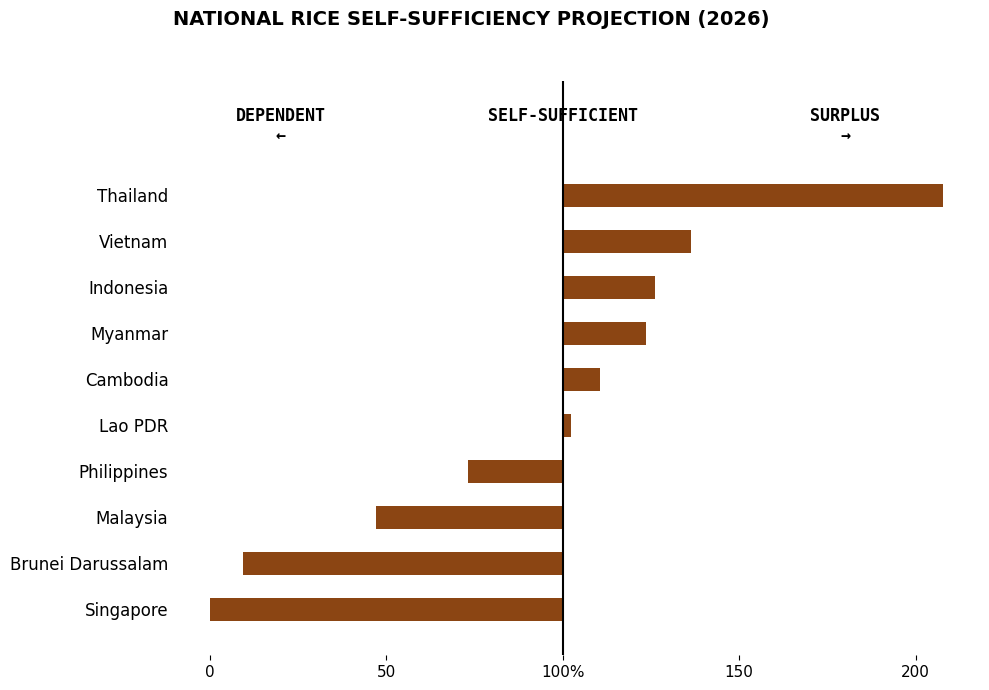

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Mendefinisikan Data SSR Tahun 2026
# (Diurutkan dari nilai terkecil ke terbesar untuk menyesuaikan tata letak diverging)
data = {
    'Country': ['Singapore', 'Brunei Darussalam', 'Malaysia', 'Philippines',
                'Lao PDR', 'Cambodia', 'Myanmar', 'Indonesia', 'Vietnam', 'Thailand'],
    'SSR_2026': [0.00, 9.38, 46.98, 73.21, 102.48, 110.66, 123.49, 126.23, 136.25, 207.88]
}

df = pd.DataFrame(data)

# 2. Transformasi Data untuk Diverging Bar
# Karena batas "Self-Sufficient" adalah 100%, kita kurangi semua nilai dengan 100.
# Nilai minus akan menjadi batang ke kiri (Dependent), nilai plus ke kanan (Surplus).
df['Centered_SSR'] = df['SSR_2026'] - 100

# 3. Pengaturan Kanvas Grafik (Tanpa Latar Abu-abu)
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
ax.set_facecolor('white')

# 4. Membuat Grafik Batang (Warna Cokelat)
brown_color = '#8B4513' # Warna Saddle Brown
ax.barh(df['Country'], df['Centered_SSR'], color=brown_color, height=0.5)

# 5. Menambahkan Garis Vertikal Tengah (Batas 100%)
ax.axvline(0, color='black', linewidth=1.5)

# 6. Kustomisasi Elemen Teks & Tata Letak ala "Gambar 2"
# Menambahkan teks kategori di bagian atas
ax.text(-80, 10.5, 'DEPENDENT\n←', ha='center', va='center', fontsize=12, fontweight='bold', fontfamily='monospace')
ax.text(0, 10.5, 'SELF-SUFFICIENT\n|', ha='center', va='center', fontsize=12, fontweight='bold', fontfamily='monospace')
ax.text(80, 10.5, 'SURPLUS\n→', ha='center', va='center', fontsize=12, fontweight='bold', fontfamily='monospace')

# Menambahkan Judul
plt.title('NATIONAL RICE SELF-SUFFICIENCY PROJECTION (2026)', loc='left', fontsize=14, fontweight='bold', pad=40)

# Menghapus garis tepi (spines) agar terlihat minimalis
for spine in ax.spines.values():
    spine.set_visible(False)

# Memperbaiki label Sumbu X agar menunjukkan nilai SSR aslinya (0% - 200%+)
# Posisi asli di grafik (centered): -100, -50, 0, 50, 100
ticks = [-100, -50, 0, 50, 100]
tick_labels = ['0', '50', '100%', '150', '200']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=11)

# Merapikan Sumbu Y (Nama Negara)
ax.tick_params(axis='y', length=0, labelsize=12) # length=0 menghilangkan garis kecil (tick marks)

# Mengatur margin agar teks atas tidak terpotong
plt.ylim(-1, 11.5)
plt.tight_layout()

# 7. Menampilkan Grafik
plt.savefig('Diverging_Bar_SSR_2026.svg', format='svg') # Menyimpan grafik sebagai file SVG
plt.show()

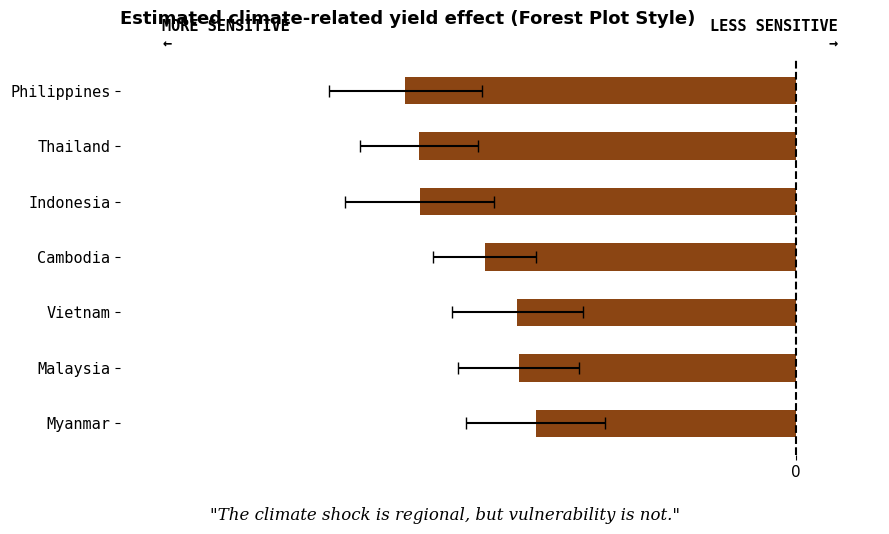

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt

# ==========================================
# 1. PERSIAPAN DAN PENGGABUNGAN DATA
# ==========================================
# Membaca data iklim
df_temp = pd.read_csv("annual-temperature-anomalies.csv")
df_rain = pd.read_csv("average-precipitation-per-year.csv")

# Memfilter untuk negara-negara ASEAN (sebagai contoh produsen)
asean_countries = ['Indonesia', 'Malaysia', 'Philippines', 'Thailand', 'Vietnam', 'Cambodia', 'Myanmar']
df_temp = df_temp[df_temp['Entity'].isin(asean_countries)]
df_rain = df_rain[df_rain['Entity'].isin(asean_countries)]

# Menggabungkan data suhu dan curah hujan berdasarkan Negara dan Tahun
df_climate = pd.merge(df_temp, df_rain, on=['Entity', 'Code', 'Year'], how='inner')

# ==========================================
# 2. PERHITUNGAN SESUAI GAMBAR 3
# ==========================================
# Menghitung Rain Anomaly (%) dari rata-rata historis per negara
df_climate['Rain_Mean'] = df_climate.groupby('Entity')['Annual precipitation'].transform('mean')
df_climate['Rain_Anomaly'] = ((df_climate['Annual precipitation'] - df_climate['Rain_Mean']) / df_climate['Rain_Mean']) * 100

# Karena data asli "Yield Anomaly" tidak ada, kita lakukan simulasi
# agar regresi (YieldAnomaly = a + b1*RainAnomaly + b2*TempAnomaly + e) bisa berjalan.
np.random.seed(42)
simulated_yields = []
for index, row in df_climate.iterrows():
    # Asumsi: Setiap negara memiliki kerentanan dasar (b1 dan b2) yang berbeda-beda
    temp_impact = -np.random.uniform(2, 6) # Suhu tinggi berdampak negatif
    rain_impact = np.random.uniform(0.05, 0.2) # Curah hujan berlebih sedikit positif/negatif tergantung batas

    error_term = np.random.normal(0, 2)
    # Menghitung simulasi yield anomaly
    yield_anom = (rain_impact * row['Rain_Anomaly']) + (temp_impact * row['Temperature anomaly']) + error_term
    simulated_yields.append(yield_anom)

df_climate['Yield_Anomaly'] = simulated_yields

# Menjalankan Regresi (OLS) per produsen untuk mencari "Climate Sensitivity"
# Kita fokus pada koefisien Suhu (TempAnomaly) sebagai indikator sensitivitas utama
results = []
for country in df_climate['Entity'].unique():
    subset = df_climate[df_climate['Entity'] == country]

    # Variabel independen (X) dan dependen (y)
    X = subset[['Rain_Anomaly', 'Temperature anomaly']]
    X = sm.add_constant(X)
    y = subset['Yield_Anomaly']

    # Fitting model
    model = OLS(y, X).fit()

    # Ekstraksi Koefisien dan 95% Confidence Interval
    temp_coef = model.params['Temperature anomaly']
    ci_lower = model.conf_int(alpha=0.05).loc['Temperature anomaly'][0]
    ci_upper = model.conf_int(alpha=0.05).loc['Temperature anomaly'][1]

    results.append({
        'Producer': country,
        'Sensitivity': temp_coef,
        'Error': ci_upper - temp_coef # Jarak error untuk plot
    })

# Membuat DataFrame hasil dan mengurutkan dari yang paling sensitif (paling negatif)
df_results = pd.DataFrame(results).sort_values('Sensitivity', ascending=True)

# ==========================================
# 3. VISUALISASI FOREST PLOT (GRAFIK BATANG)
# ==========================================
# Pengaturan kanvas dengan latar belakang putih murni
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')

# Menentukan warna batang cokelat
brown_color = '#8B4513'

# Membuat Bar Chart Horizontal (Diverging bar chart yang bertindak sebagai forest plot)
y_pos = np.arange(len(df_results))
ax.barh(y_pos, df_results['Sensitivity'], xerr=df_results['Error'],
        align='center', color=brown_color, edgecolor='none', height=0.5, capsize=4)

# Menambahkan garis vertikal di angka 0 (sebagai baseline/titik netral)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')

# Kustomisasi Sumbu Y (Nama Produsen)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_results['Producer'], fontsize=11, fontfamily='monospace')
ax.invert_yaxis()  # Membalik sumbu Y agar yang paling sensitif berada di atas

# Kustomisasi Sumbu X & Teks Anotasi ala "Gambar 4"
ax.set_xlim(-8, 1) # Menyesuaikan batas X dengan data hasil regresi
ax.set_xticks([0])
ax.set_xticklabels(['0'], fontsize=11)

# Menambahkan teks petunjuk sensitivitas di bagian atas grafik
ax.text(-7.5, -1, 'MORE SENSITIVE\n←', ha='left', va='center', fontsize=11, fontweight='bold', fontfamily='monospace')
ax.text(0.5, -1, 'LESS SENSITIVE\n→', ha='right', va='center', fontsize=11, fontweight='bold', fontfamily='monospace')

# Menambahkan Judul dan Kutipan di bawah grafik
plt.title('Estimated climate-related yield effect (Forest Plot Style)', loc='left', fontsize=13, fontweight='bold', pad=25)
plt.figtext(0.5, -0.05, '"The climate shock is regional, but vulnerability is not."',
            ha="center", fontsize=12, style='italic', fontfamily='serif')

# Menghilangkan garis tepi agar terlihat rapi dan bersih
for spine in ax.spines.values():
    spine.set_visible(False)

# Merapikan layout
plt.tight_layout()
plt.show()